In [187]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import os
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score, recall_score, classification_report,f1_score, multilabel_confusion_matrix, ConfusionMatrixDisplay

In [188]:
dataset_path = ['1. Immagini/', '2. Video/']

In [189]:
oracolo_img_PATH = "Oracolo_Binar_Img.csv"
oracolo_video_PATH = "Oracolo_Binary_Video.csv"

llm_img_PATH = "Binario - Contenuti MultiMediali_soloImmagini.csv"
llm_video_PATH = "Contenuti MultiMediali_soloVideo.csv"

In [190]:
def load_df(path_directory):
  return pd.read_csv(f"{path_directory}", sep=";", on_bad_lines="skip")

In [191]:
oracolo_img_df = load_df(f'{dataset_path[0]}Oracolo_Binar_Img.csv')
oracolo_video_df = load_df(f'{dataset_path[1]}Oracolo_Binary_Video.csv')

llm_img_df = load_df(f'{dataset_path[0]}Binario - Contenuti MultiMediali_soloImmagini.csv')
llm_video_df = load_df(f'{dataset_path[1]}Contenuti MultiMediali_soloVideo.csv')

In [192]:
llm_video_df.head()

,Collegamento,Label_gemini-1.0-pro-vision,Label_gemini-1.5-flash,Label_gemini-1.5-pro
0,Kaiber\Kaiber_4.mp4,0,0,0
1,Runway\Runway_0.mp4,0,1,0
2,Runway\Runway_1.mp4,1,1,1
3,Runway\Runway_2.mp4,1,1,1
4,Runway\Runway_3.mp4,0,1,1


In [193]:
llm_img_df.head()

,Collegamento,Label_GPT4,Label_Haiku,Label_Sonnet
0,Kaiber\Kaiber_0.png,1,0,0
1,Kaiber\Kaiber_1.png,1,0,0
2,Kaiber\Kaiber_2.png,1,0,0
3,Kaiber\Kaiber_3.png,1,0,0
4,Kaiber\Kaiber_5.png,1,0,0


In [194]:
oracolo_img_df.head()

,Collegamento,Label
0,Kaiber\Kaiber_0.png,0
1,Kaiber\Kaiber_1.png,0
2,Kaiber\Kaiber_2.png,0
3,Kaiber\Kaiber_3.png,0
4,Kaiber\Kaiber_5.png,0


In [195]:
def load_label_img(oracolo_img_df, llm_img_df):
    y_true_img = list(oracolo_img_df['Label'])

    y_pred_GPT4 = list(llm_img_df['Label_GPT4'])
    y_pred_Haiku = list(llm_img_df['Label_Haiku'])
    y_pred_Sonnet = list(llm_img_df['Label_Sonnet'])

    print('true: ' , set(y_true_img), 'len: ', len(set(y_true_img)))
    print('GPT4 pred: ' , set(y_pred_GPT4), 'len: ', len(set(y_pred_GPT4)))
    print('Haiku pred: ' , set(y_pred_Haiku), 'len: ', len(set(y_pred_Haiku)))
    print('Sonnet pred: ' , set(y_pred_Sonnet), 'len: ', len(set(y_pred_Sonnet)))

    return y_true_img, y_pred_GPT4, y_pred_Haiku, y_pred_Sonnet

In [196]:
def load_label_video(oracolo_video_df, llm_video_df):
    y_true_video = list(oracolo_video_df['Label'])

    y_pred_gemini_pro_vision = list(llm_video_df['Label_gemini-1.0-pro-vision'])
    y_pred_gemini_flash = list(llm_video_df['Label_gemini-1.5-flash'])
    y_pred_gemini_pro= list(llm_video_df['Label_gemini-1.5-pro'])

    print('true: ' , set(y_true_video), 'len: ', len(set(y_true_video)))
    print('gemini_pro_vision pred: ' , set(y_pred_gemini_pro_vision), 'len: ', len(set(y_pred_gemini_pro_vision)))
    print('gemini_flash pred: ' , set(y_pred_gemini_flash), 'len: ', len(set(y_pred_gemini_flash)))
    print('gemini_pro pred: ' , set(y_pred_gemini_pro), 'len: ', len(set(y_pred_gemini_pro)))

    return y_true_video, y_pred_gemini_pro_vision, y_pred_gemini_flash, y_pred_gemini_pro

In [197]:
def compute_metrics(y_true, y_pred, label, average):
    Accuracy = accuracy_score(y_true, y_pred)
    Precision = precision_score(y_true, y_pred, labels=label, average=average)
    Sensitivity_recall = recall_score(y_true, y_pred, labels=label, average=average)
    F1_score = f1_score(y_true, y_pred, labels=label, average=average)

    confusion = confusion_matrix(y_true, y_pred)

    evaluation_report = classification_report(y_true, y_pred, labels=label, target_names=['Etici', 'Non Etici'])
    
    return Accuracy, Precision, Sensitivity_recall, F1_score, confusion, evaluation_report

In [198]:
def conf_matrix(y_true, y_pred, label, path, LLM):
    averages = ['micro', 'macro', 'weighted', 'binary']
    
    for average in averages:
      Accuracy, Precision, Sensitivity_recall, F1_score, confusion, evaluation_report = compute_metrics(y_true, y_pred, label, average)

      cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion, display_labels=['Etici', 'Non Etici'])
      plt.rcParams["figure.figsize"] = (10,10)
      cm_display.plot(cmap=plt.cm.Greens, colorbar=True)
      plt.xticks(rotation = 90)
      plt.tight_layout()
      plt.savefig(f"{path}/Result/{LLM}/confusion-matrix_{LLM}_{average}.pdf")

      with open(f"{path}/Result/{LLM}/Metrics_predictions_{LLM}_{average}.txt", "w") as f:
        f.write(f"{evaluation_report}\nMetrics:\nAccuracy_score: {Accuracy}\nPrecision_score: {Precision}\nRecall_score: {Sensitivity_recall}\nF1_Score: {F1_score}")

In [199]:
def save(path, df):
    df.to_csv(path, sep=";", index=None)

In [200]:
label=['0', '1']

# Immagini

In [201]:
y_true_img, y_pred_GPT4, y_pred_Haiku, y_pred_Sonnet = load_label_img(oracolo_img_df, llm_img_df)

true:  {0, 1} len:  2
GPT4 pred:  {0, 1} len:  2
Haiku pred:  {0, 1} len:  2
Sonnet pred:  {0, 1} len:  2


## GPT4

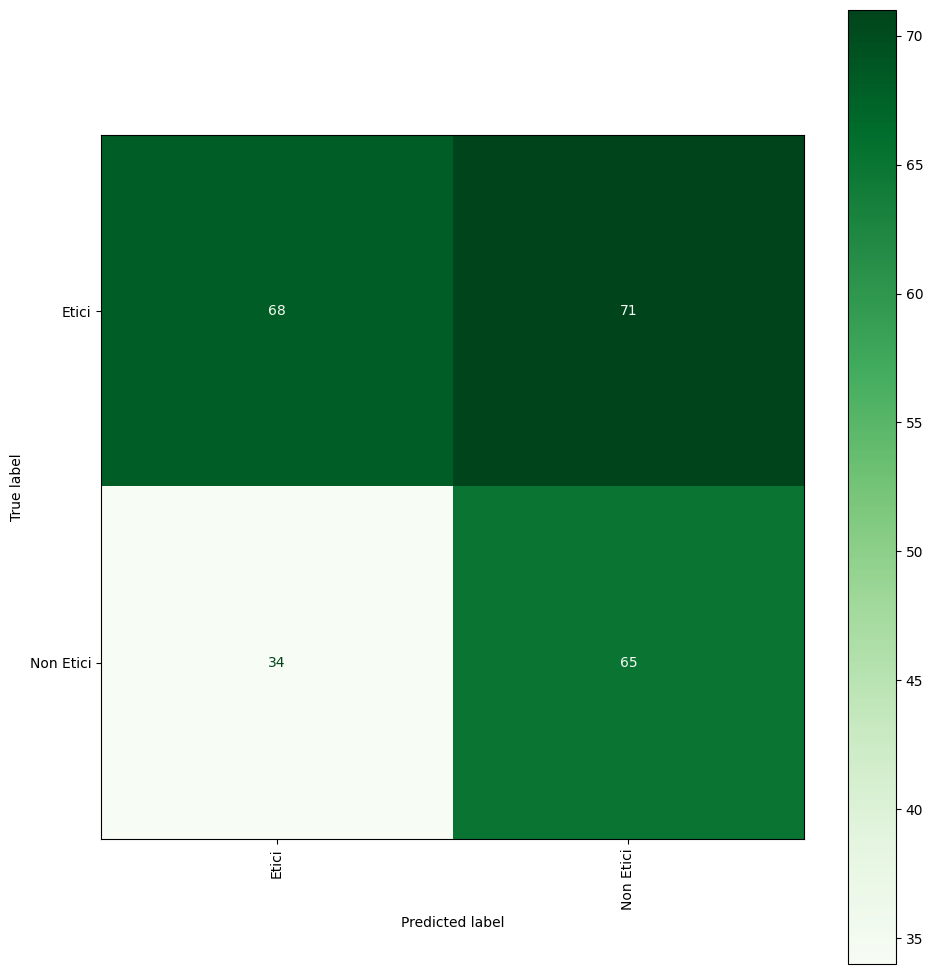

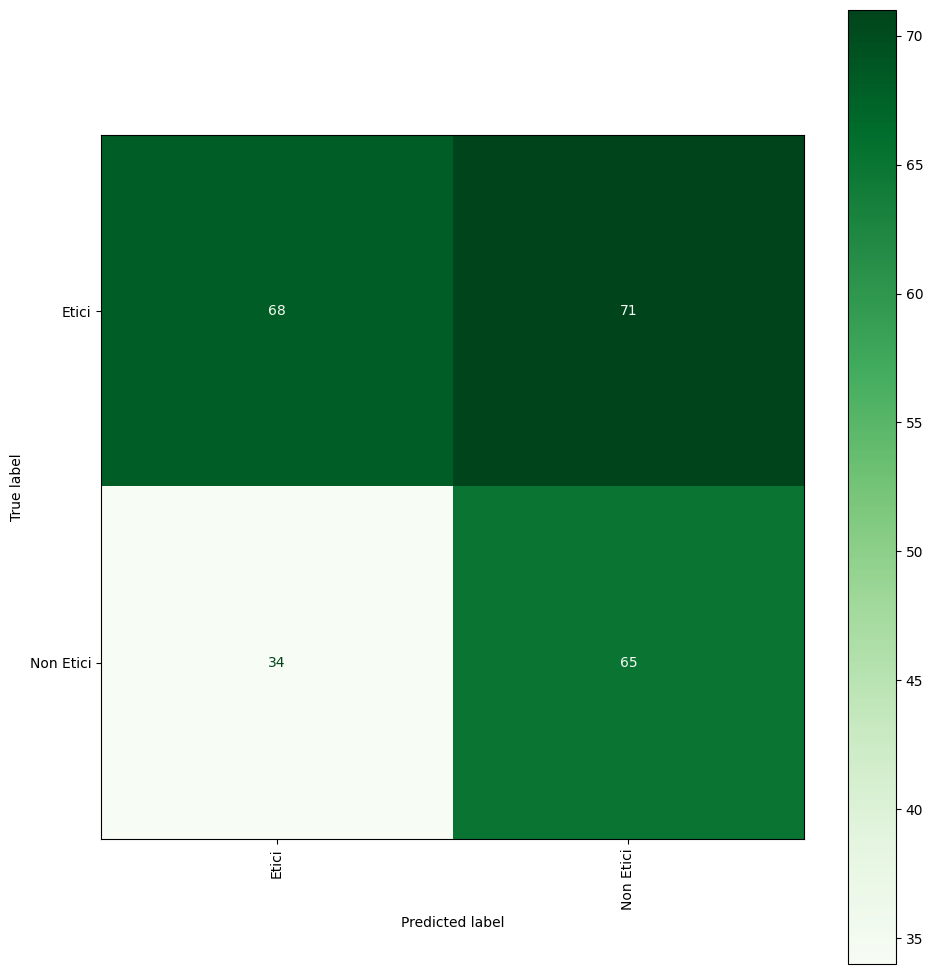

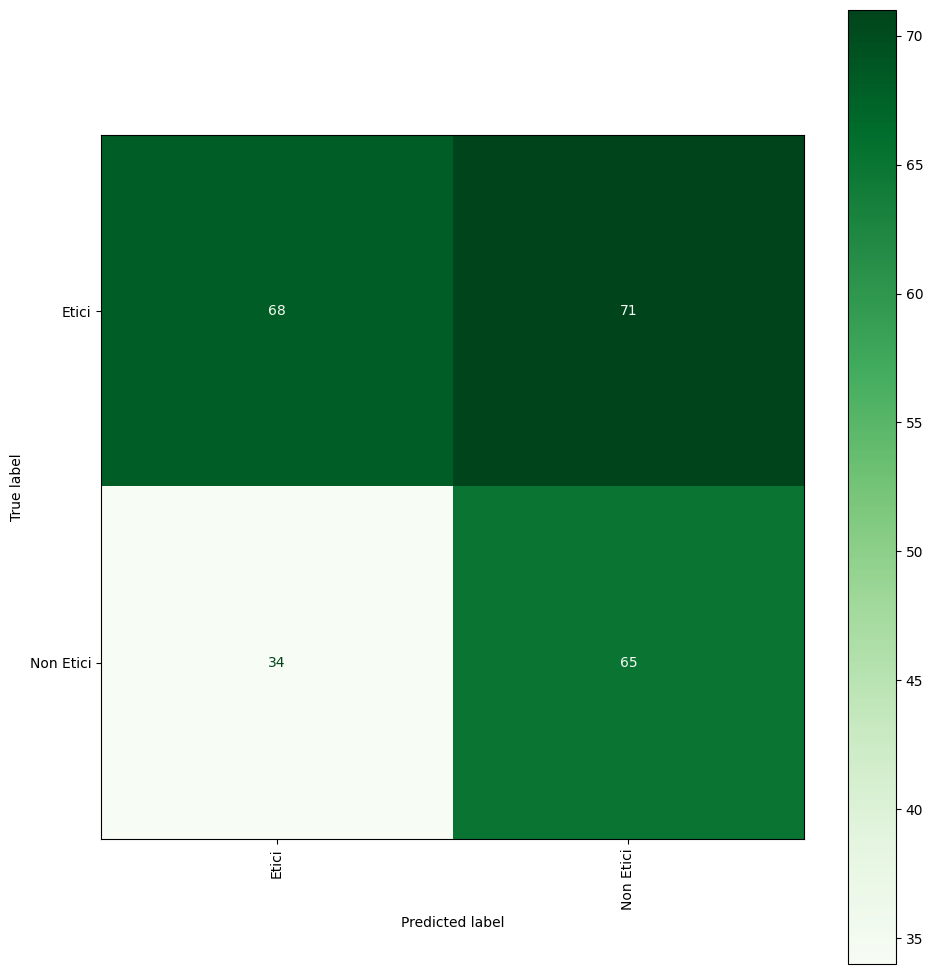

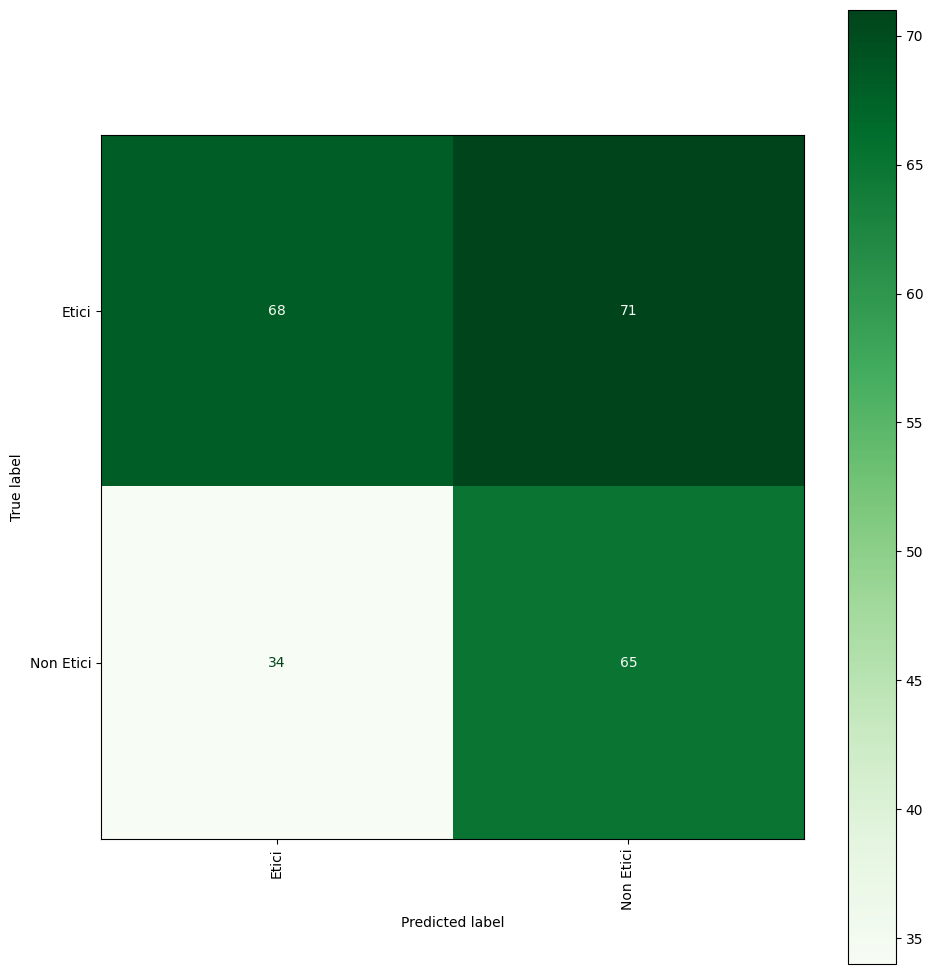

In [202]:
conf_matrix(y_true = y_true_img, y_pred= y_pred_GPT4, label= label, path= dataset_path[0], LLM = 'GPT4')

## Haiku

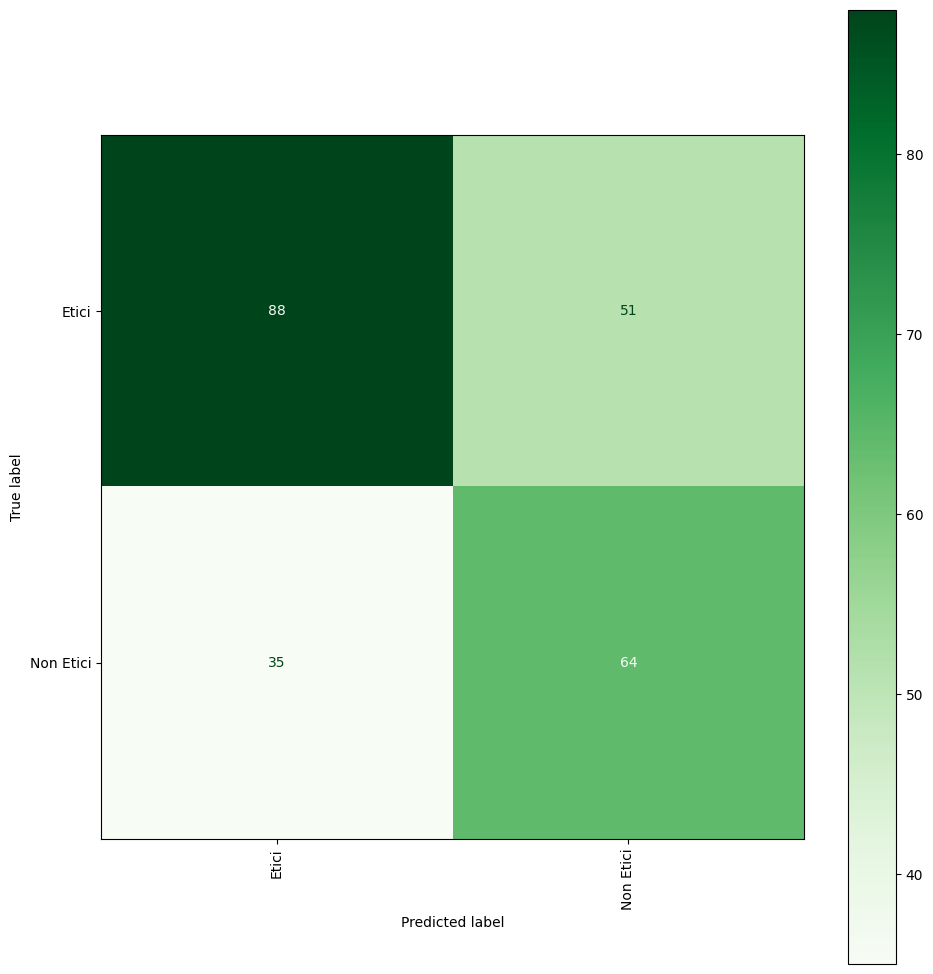

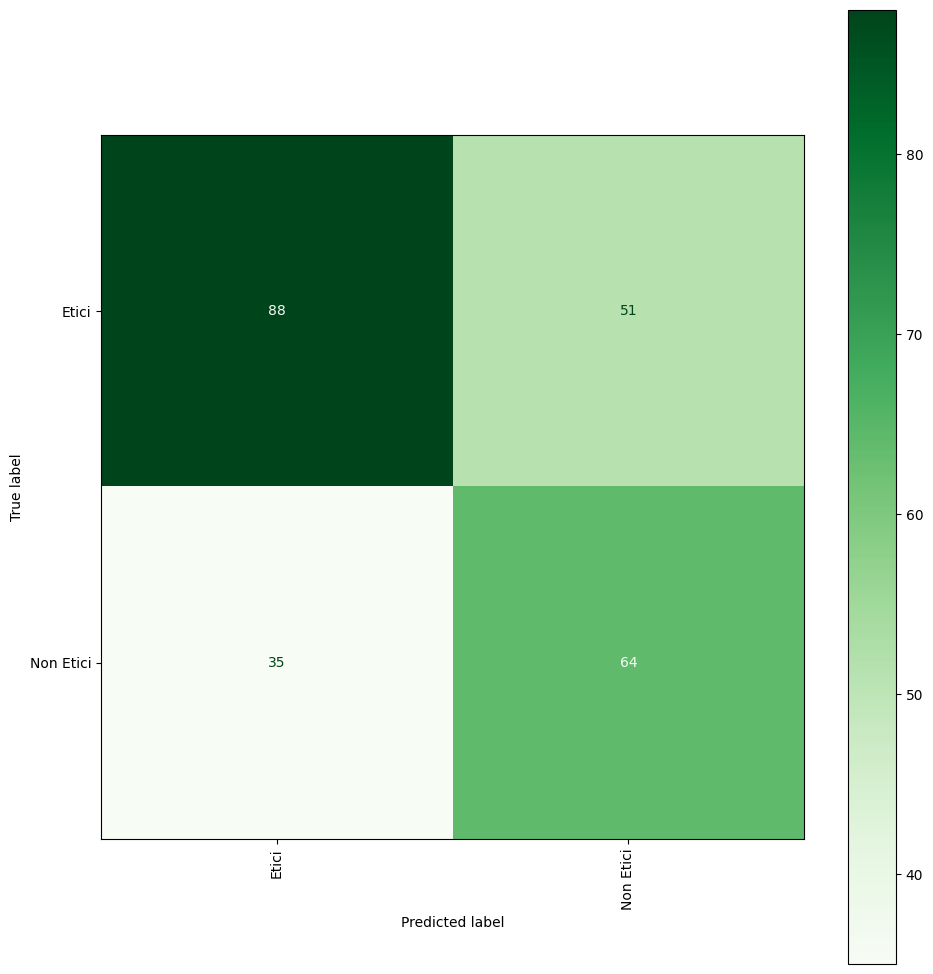

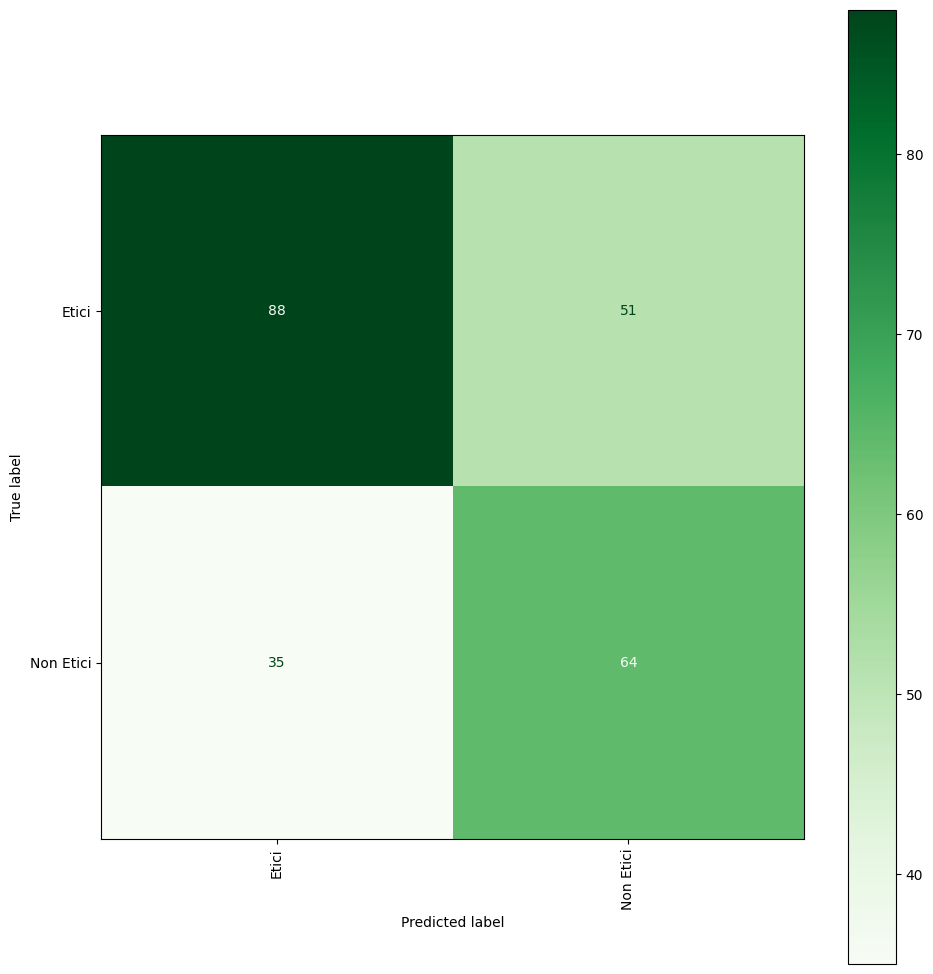

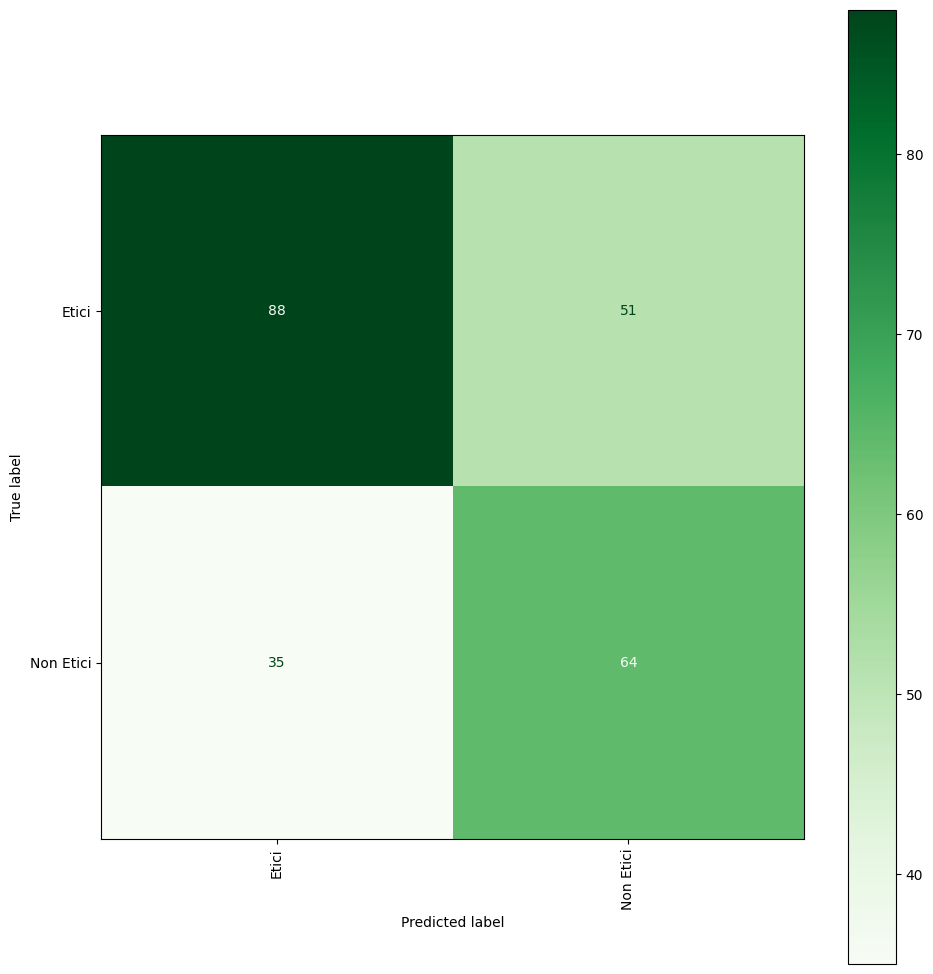

In [203]:
conf_matrix(y_true = y_true_img, y_pred= y_pred_Haiku, label= label, path= dataset_path[0], LLM = 'Haiku')

## Sonnet

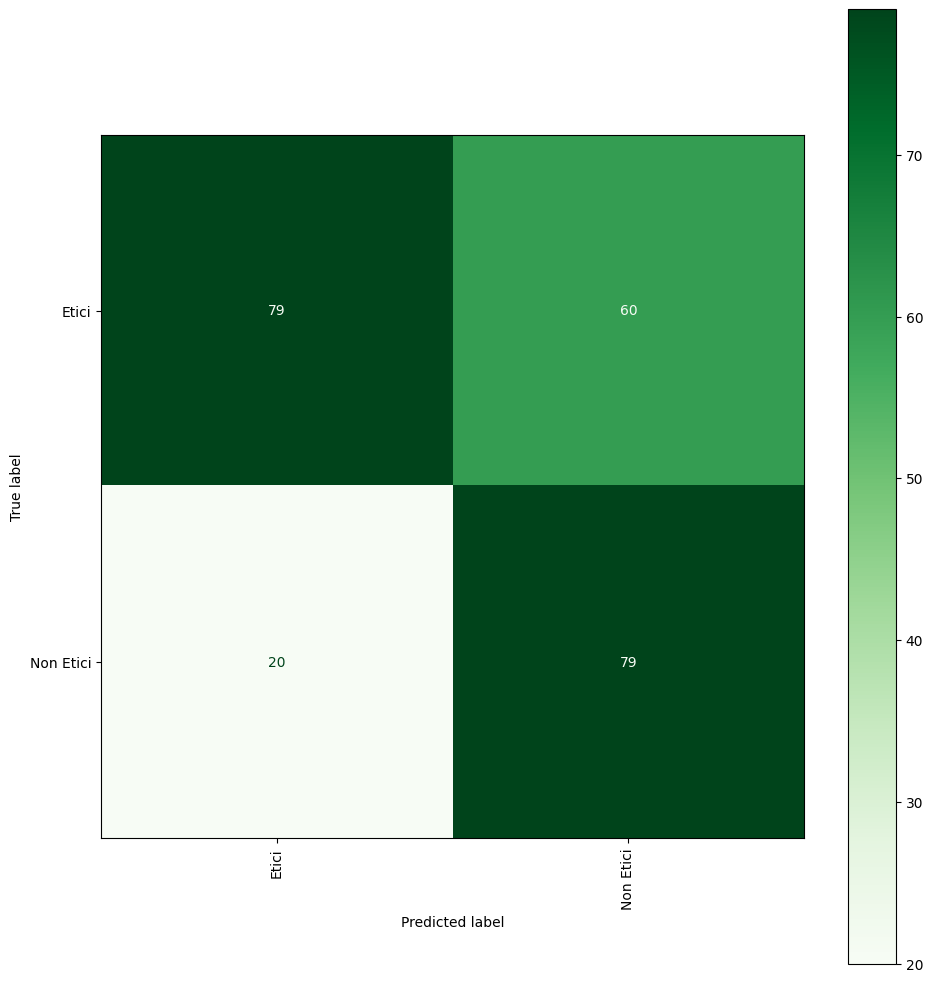

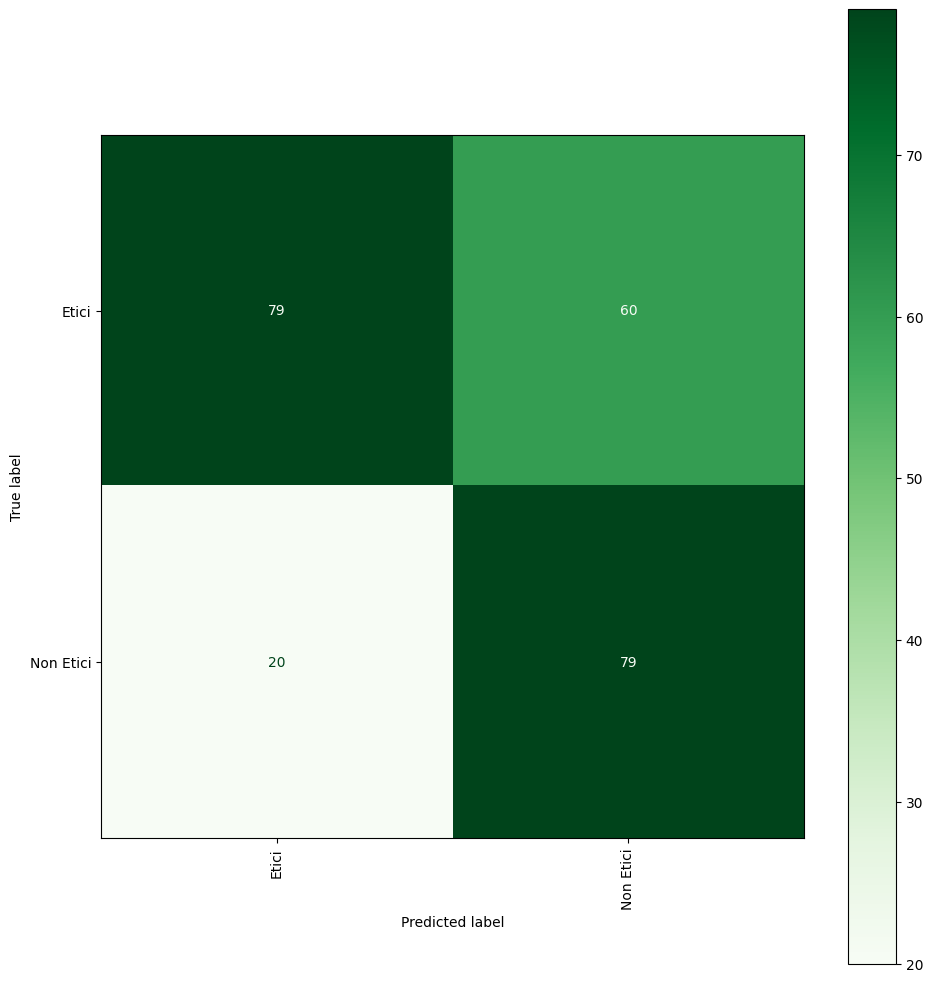

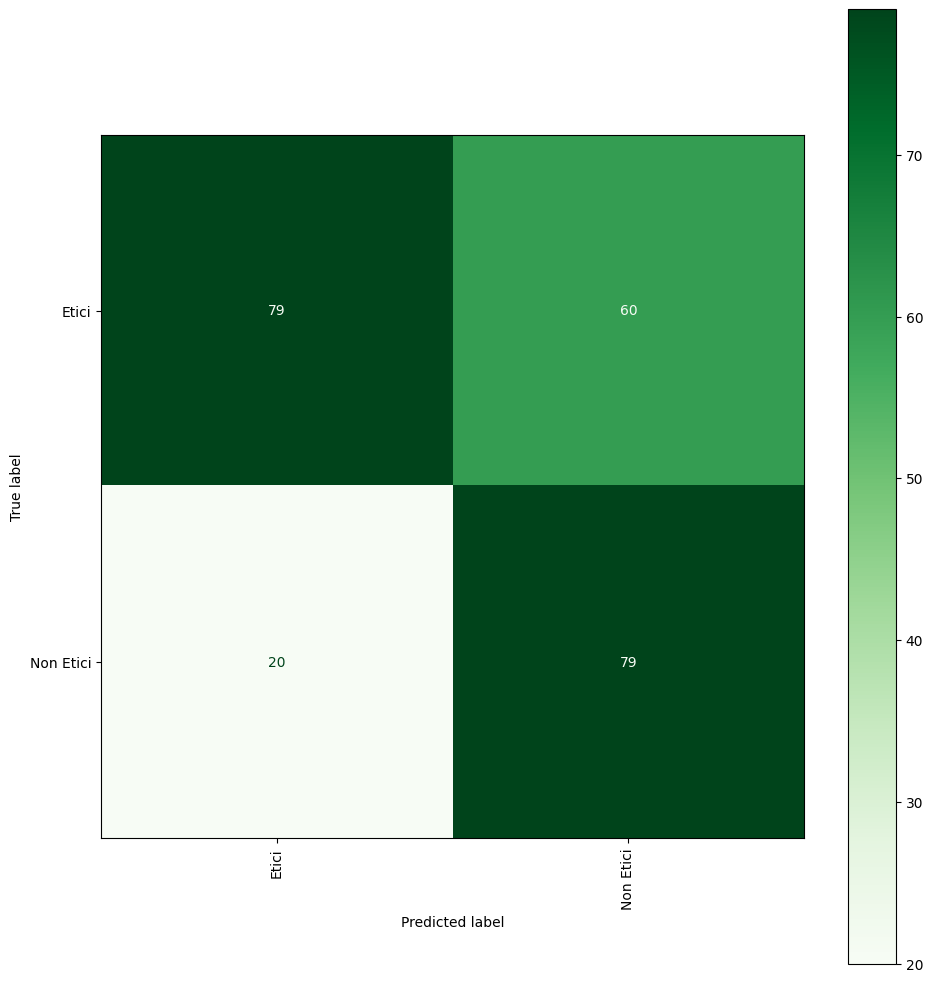

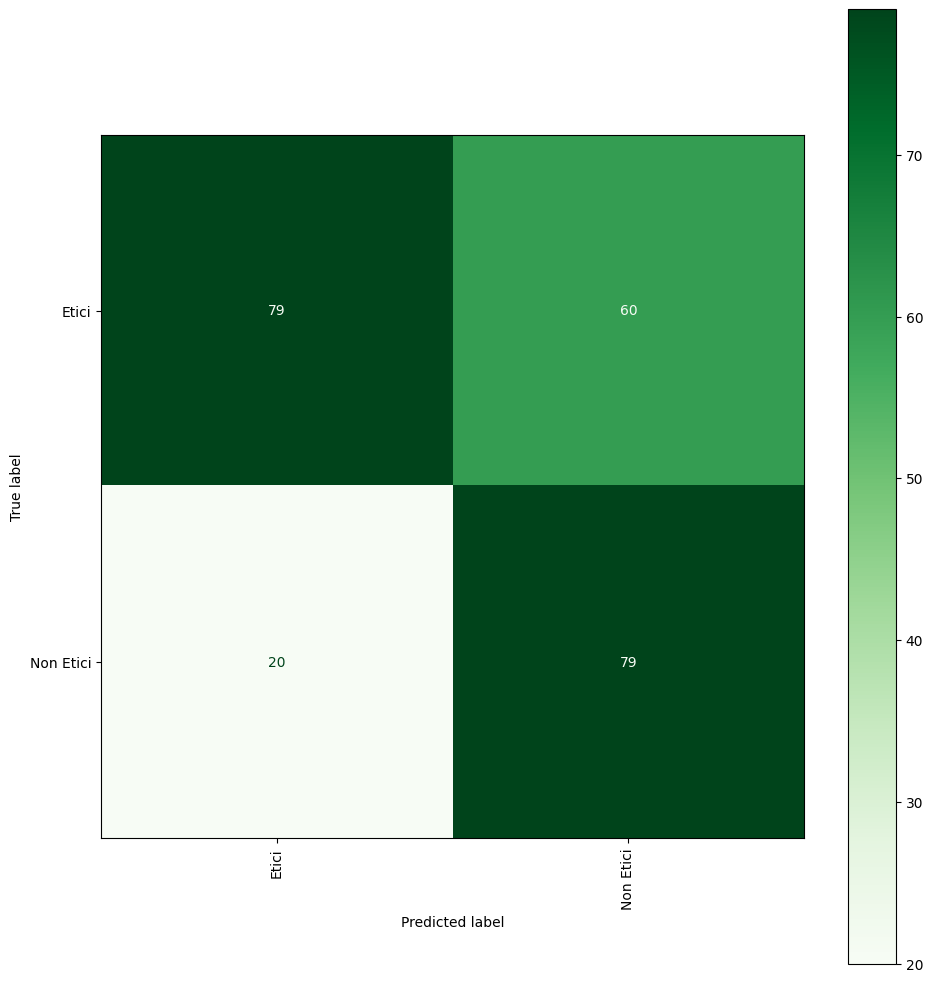

In [204]:
conf_matrix(y_true = y_true_img, y_pred= y_pred_Sonnet, label= label, path= dataset_path[0], LLM = 'Sonnet')

# Video

In [205]:
y_true_video, y_pred_gemini_pro_vision, y_pred_gemini_flash, y_pred_gemini_pro = load_label_video(oracolo_video_df, llm_video_df)

true:  {0, 1} len:  2
gemini_pro_vision pred:  {0, 1} len:  2
gemini_flash pred:  {0, 1} len:  2
gemini_pro pred:  {0, 1} len:  2


## Gemini-1.0-pro-vision

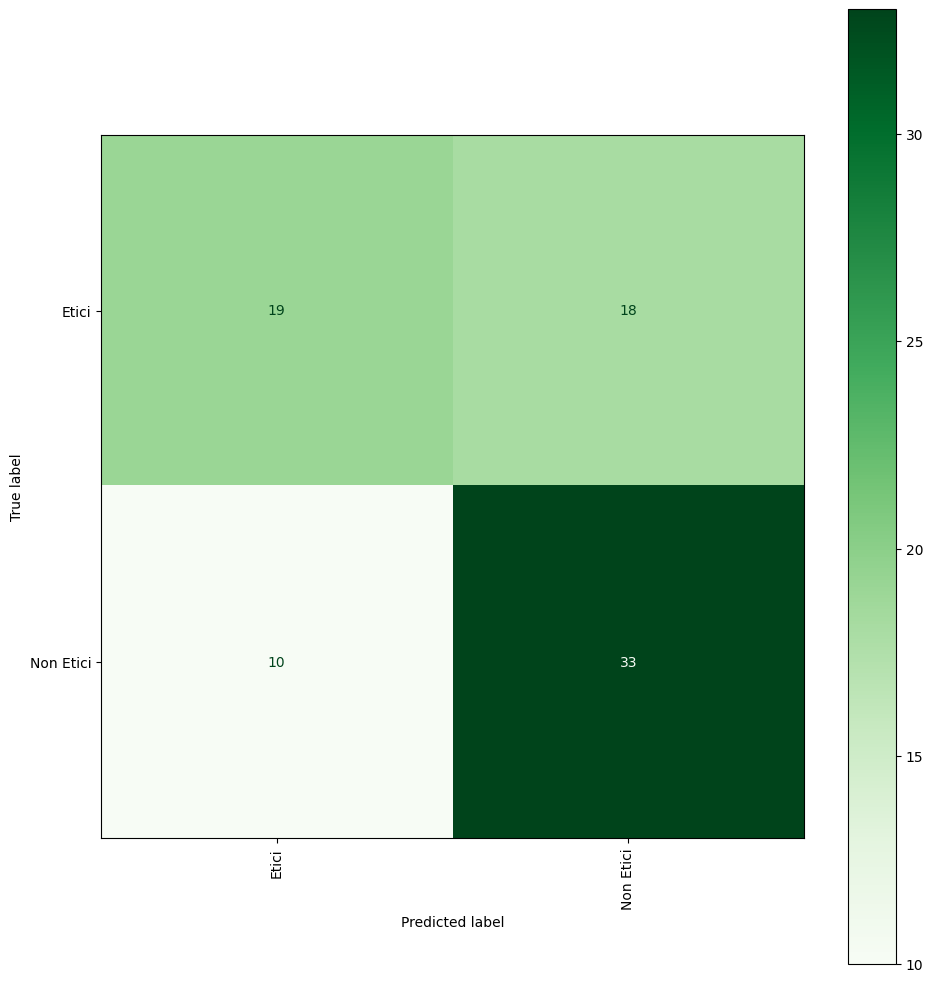

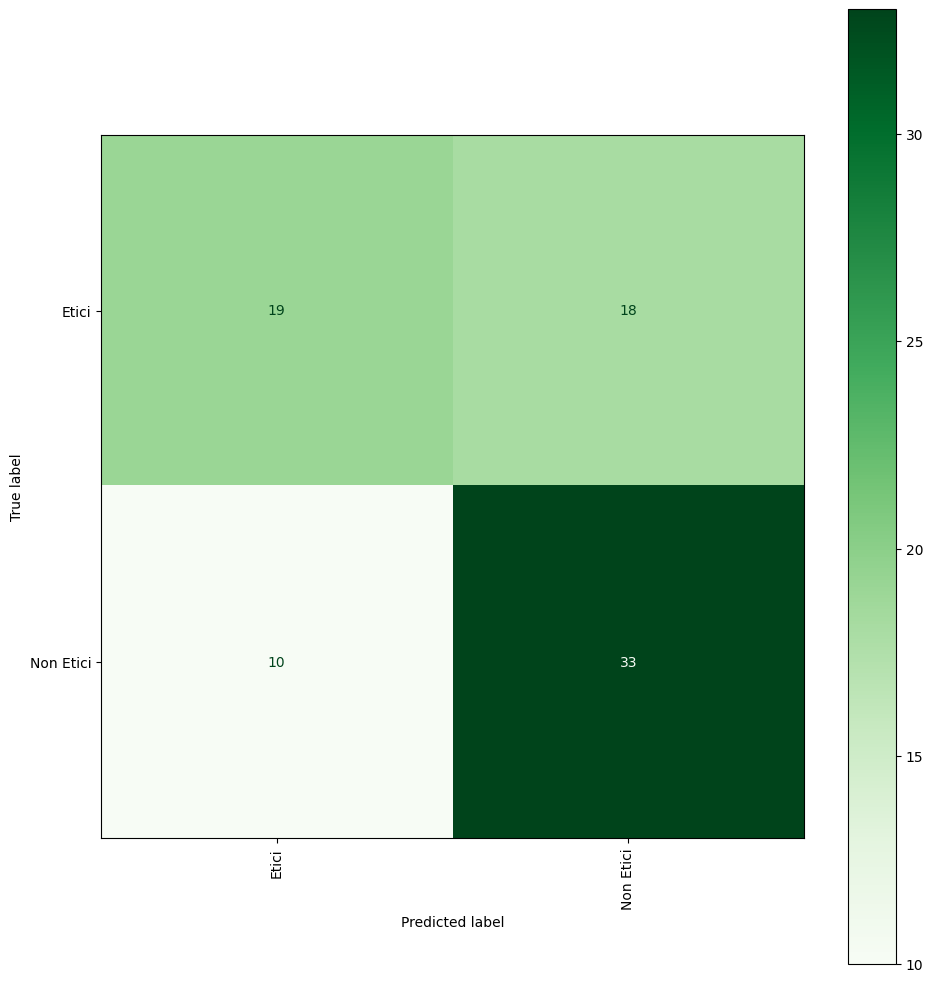

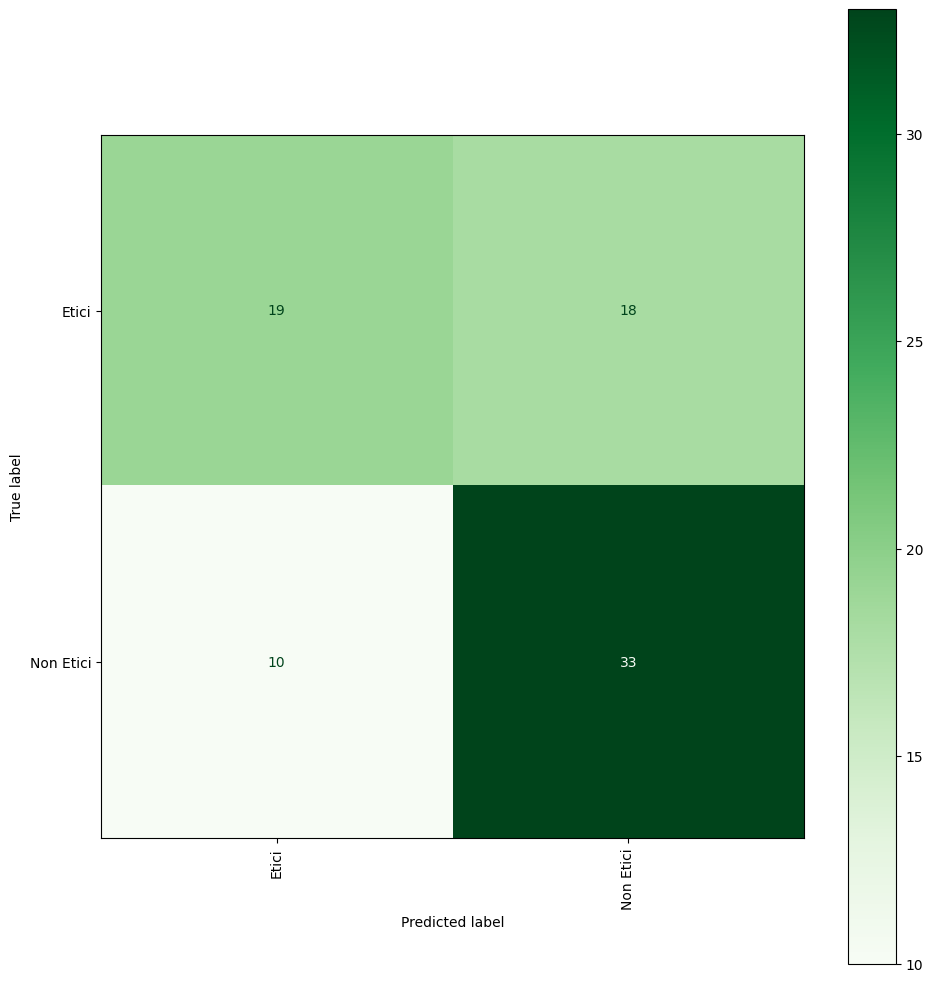

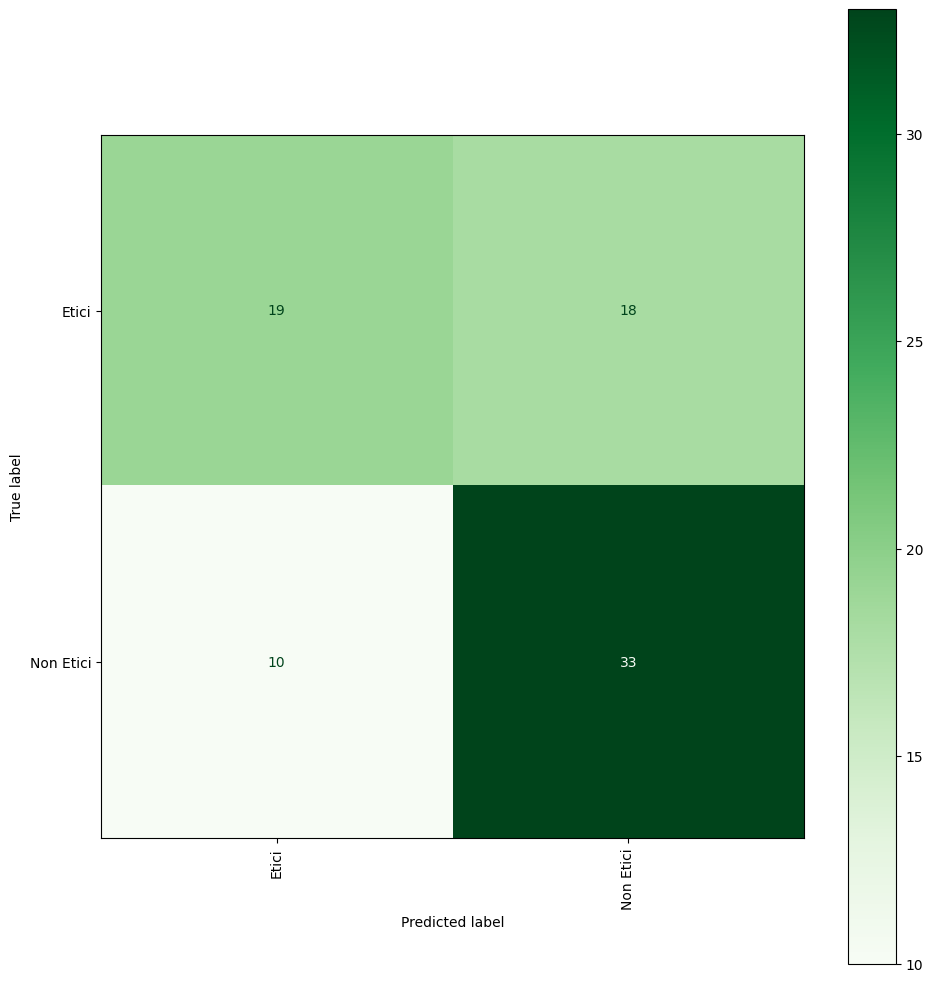

In [206]:
conf_matrix(y_true = y_true_video, y_pred= y_pred_gemini_pro_vision, label= label, path= dataset_path[1], LLM = 'Gemini-1.0-pro-vision')

## Gemini-1.5-flash

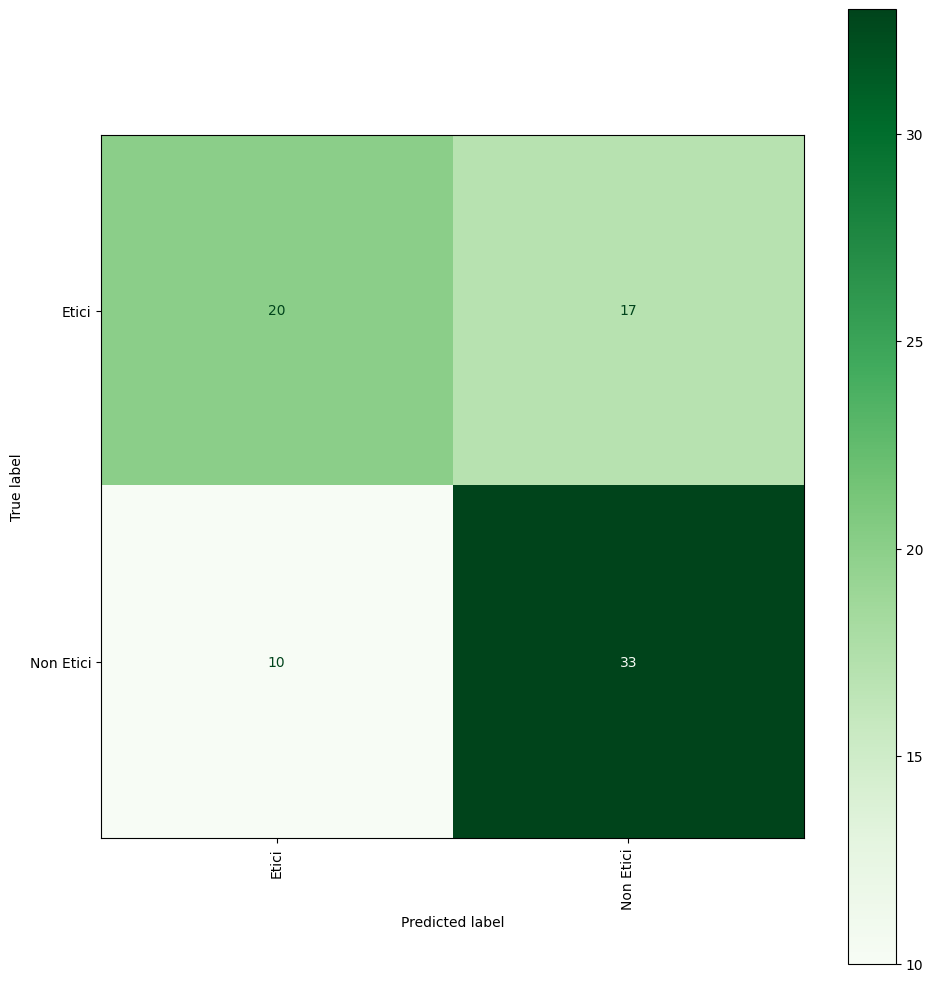

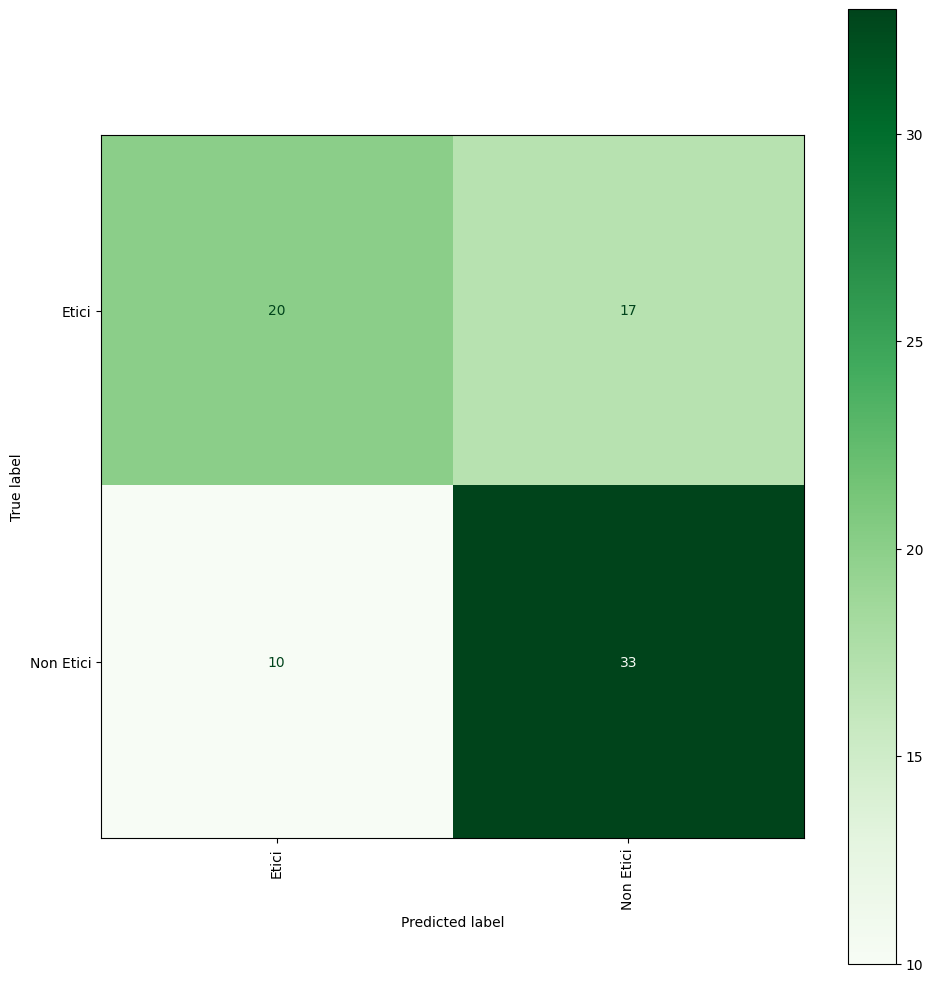

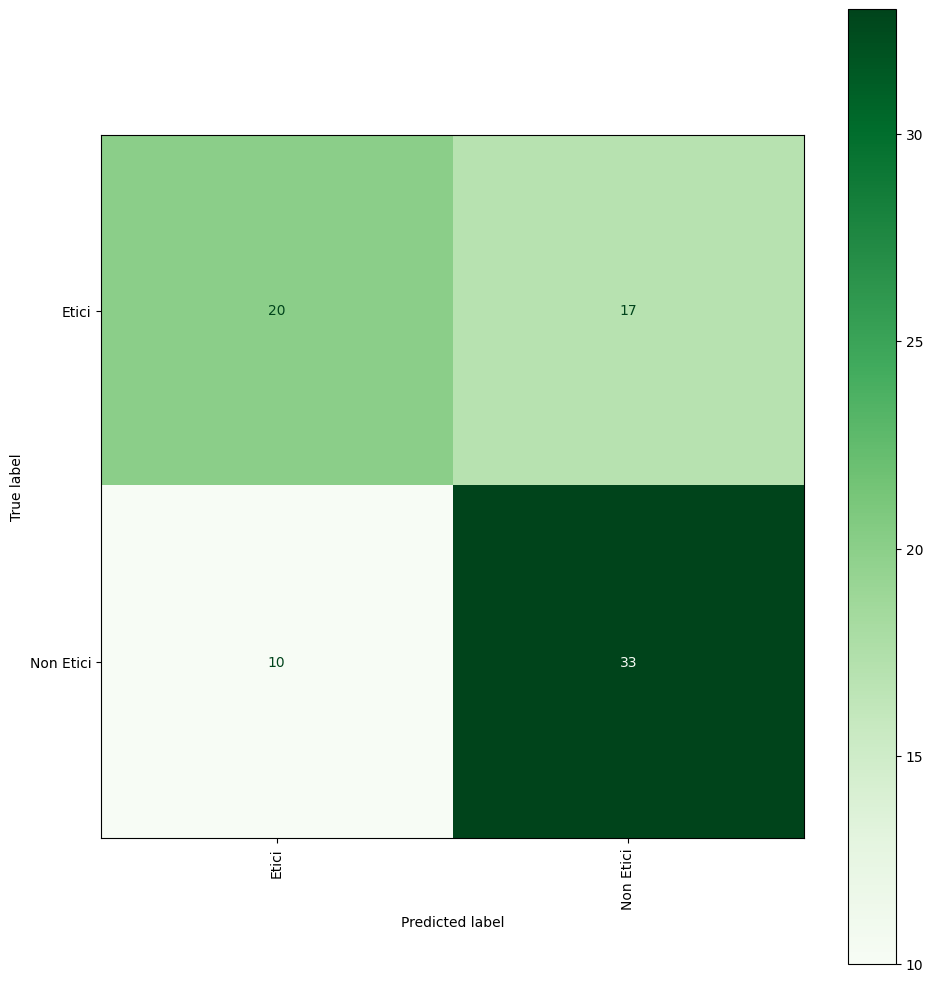

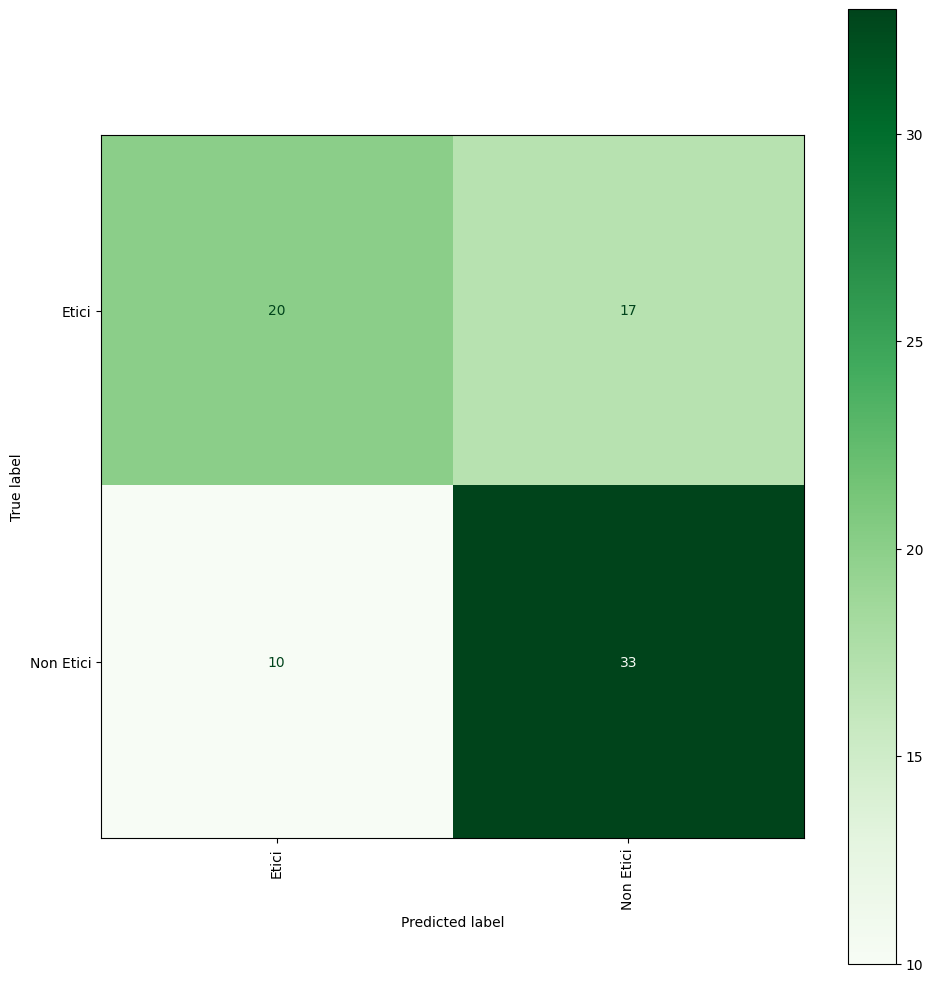

In [207]:
conf_matrix(y_true = y_true_video, y_pred= y_pred_gemini_flash, label= label, path= dataset_path[1], LLM = 'Gemini-1.5-flash')

## Gemini-1.5-pro

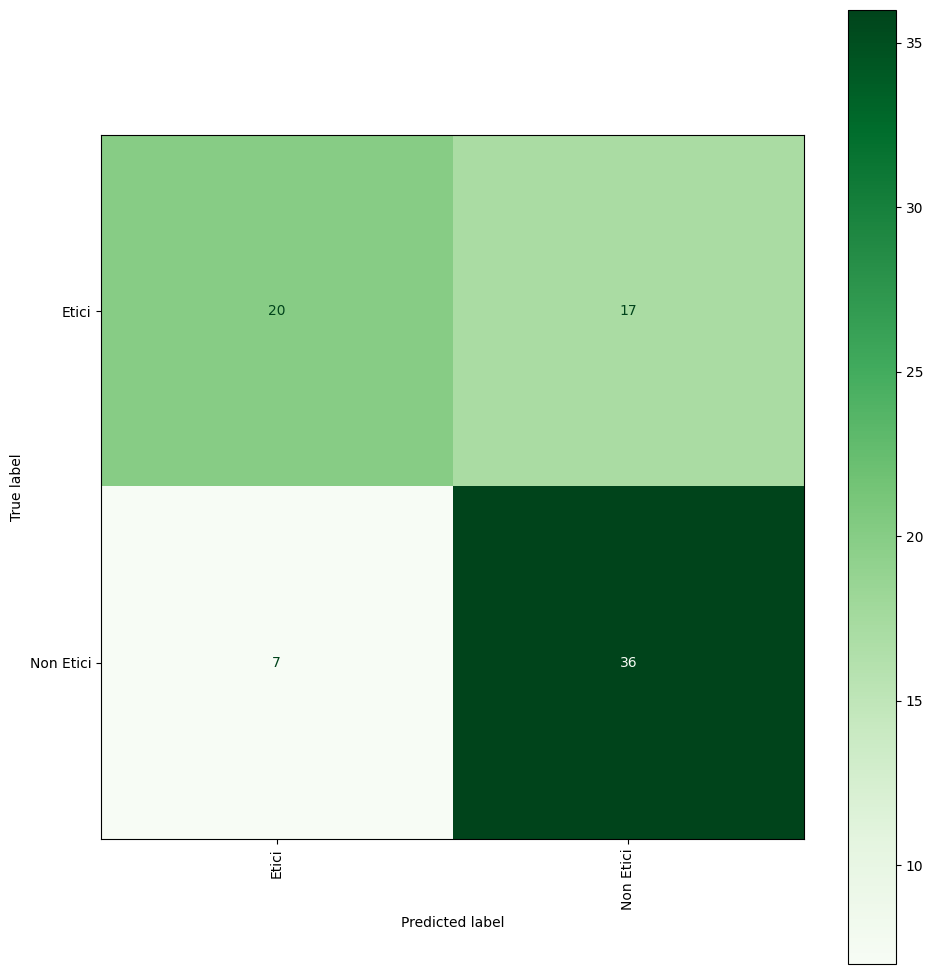

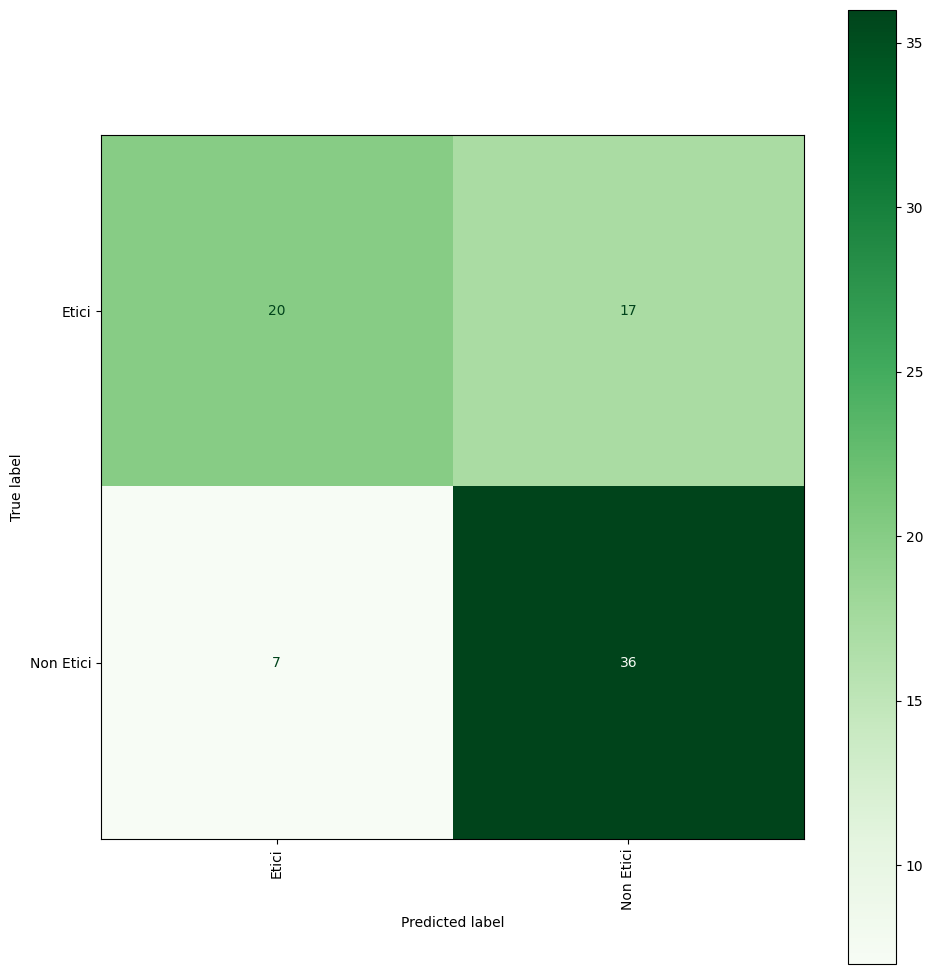

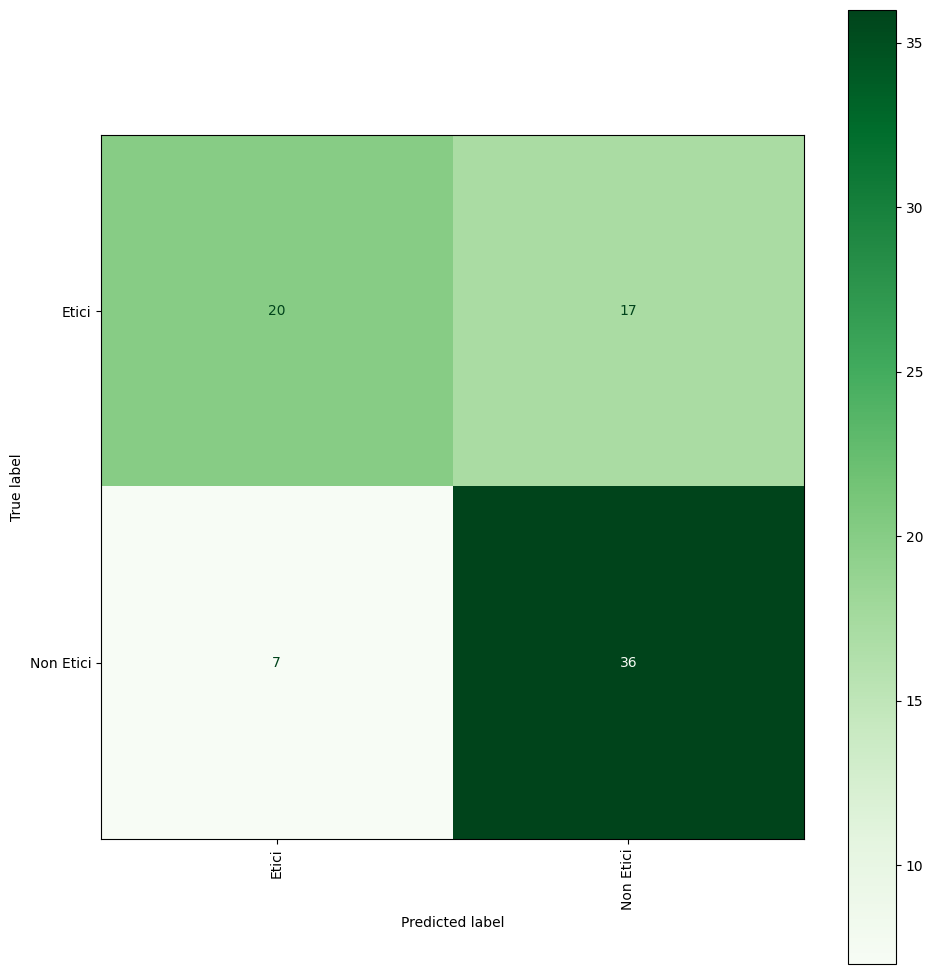

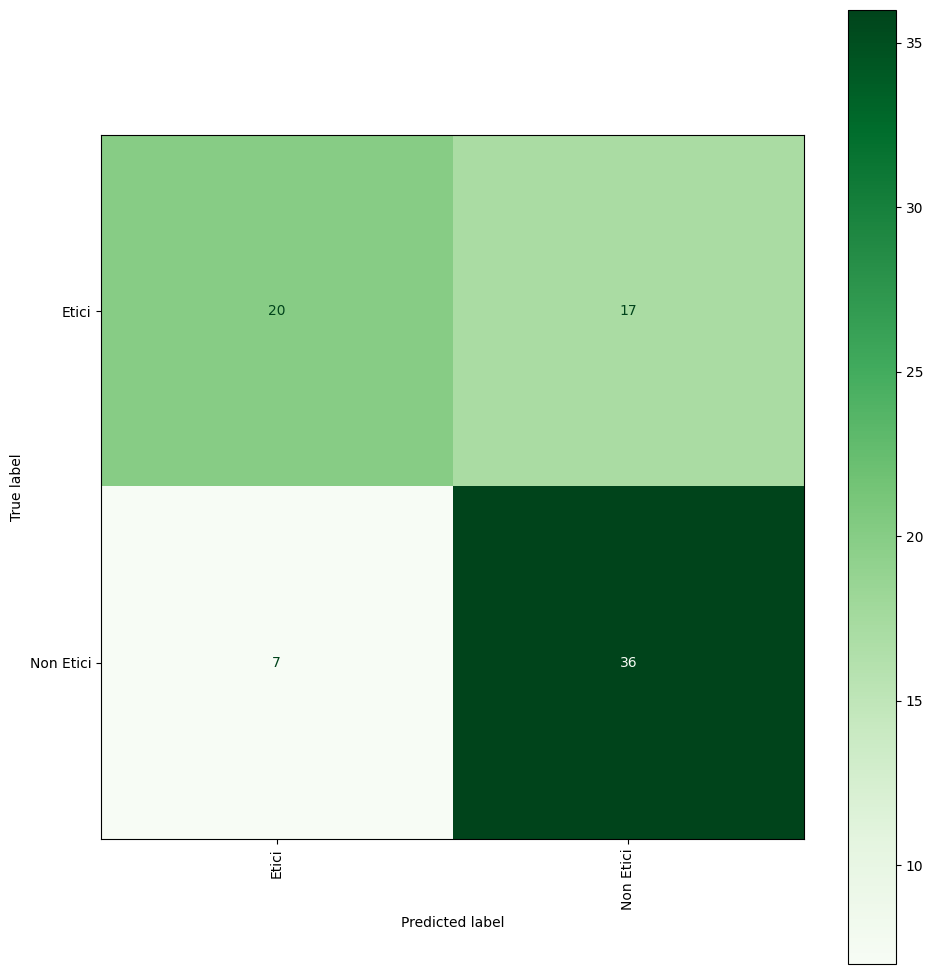

In [208]:
conf_matrix(y_true = y_true_video, y_pred= y_pred_gemini_pro, label= label, path= dataset_path[1], LLM = 'Gemini-1.5-pro')